In [1]:
!git clone https://github.com/mohamadghoroobi/tkh-hierarchy-project

Cloning into 'tkh-hierarchy-project'...
remote: Enumerating objects: 25, done.
remote: Counting objects: 100% (25/25), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 25 (delta 6), reused 18 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (25/25), 270.54 KiB | 7.73 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd /content/tkh-hierarchy-project

/content/tkh-hierarchy-project


In [3]:
!ls

data  LICENSE  notebooks  README.md  snapshot_metadata.json


# Section 3 — T1 Descriptive Statistics

## 1. Load data

### Imports

In [4]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Paths

In [5]:
PROJECT_DIR = Path(
    "/content/tkh-hierarchy-project"
)

DATA_DIR = PROJECT_DIR / "data"


TKH_PATH = DATA_DIR / "tkh_collection10.json"

### Load TKH

In [6]:
with open(
    TKH_PATH,
    "r",
    encoding="utf-8"
) as f:
    tkh = json.load(f)


nodes = tkh["nodes"]
hyperedges = tkh["hyperedges"]


print(
    f"Nodes: {len(nodes):,}"
)

print(
    f"Hyperedges: {len(hyperedges):,}"
)

Nodes: 5,798
Hyperedges: 1,429


## 2. Load temporal snapshots

In [7]:
SNAPSHOT_YEARS = [
    2020,
    2022,
    2024,
    2026
]

### Rebuild snapshots

#### Node visibility

In [8]:
def node_available_at_time(node, year):

    return (
        node["first_seen_year"]
        <=
        year
    )

#### Build nodes

In [9]:
def build_node_snapshot(nodes, year):

    return [
        node
        for node in nodes
        if node_available_at_time(
            node,
            year
        )
    ]

#### Hyperedge visibility

In [10]:
def edge_available_at_time(
    edge,
    available_nodes
):

    return all(
        member in available_nodes
        for member in edge["members"]
    )

#### Build edges

In [11]:
def build_edge_snapshot(
    hyperedges,
    available_nodes
):

    return [
        edge
        for edge in hyperedges
        if edge_available_at_time(
            edge,
            available_nodes
        )
    ]

### Generate snapshots

In [12]:
node_snapshots = {}
edge_snapshots = {}


for year in SNAPSHOT_YEARS:

    nodes_t = build_node_snapshot(
        nodes,
        year
    )

    node_snapshots[year] = nodes_t


    node_ids = {
        n["id"]
        for n in nodes_t
    }


    edges_t = build_edge_snapshot(
        hyperedges,
        node_ids
    )

    edge_snapshots[year] = edges_t


    print(
        year,
        "nodes:",
        len(nodes_t),
        "edges:",
        len(edges_t)
    )

2020 nodes: 1505 edges: 374
2022 nodes: 2164 edges: 529
2024 nodes: 4164 edges: 983
2026 nodes: 5798 edges: 1429


## 3. Temporal growth statistics

In [13]:
temporal_stats = []


for year in SNAPSHOT_YEARS:

    temporal_stats.append({

        "year": year,

        "nodes":
            len(node_snapshots[year]),

        "hyperedges":
            len(edge_snapshots[year])

    })


temporal_df = pd.DataFrame(
    temporal_stats
)


temporal_df

,year,nodes,hyperedges
0,2020,1505,374
1,2022,2164,529
2,2024,4164,983
3,2026,5798,1429


## 4. Plot growth

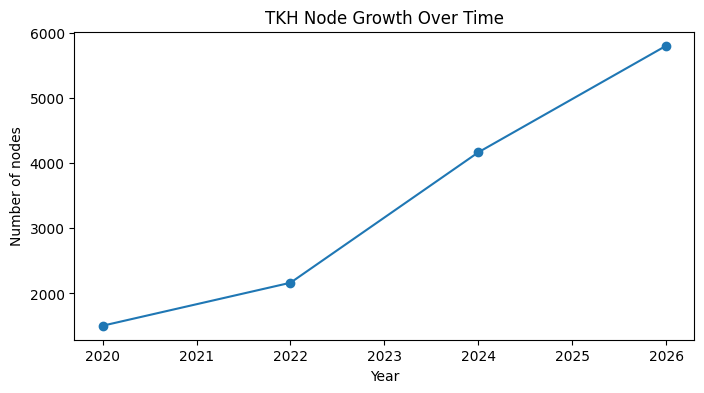

In [14]:
plt.figure(figsize=(8,4))

plt.plot(
    temporal_df["year"],
    temporal_df["nodes"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of nodes")
plt.title("TKH Node Growth Over Time")

plt.show()

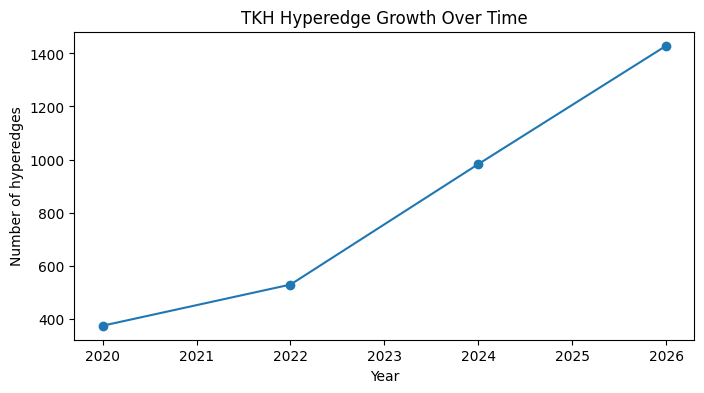

In [15]:
plt.figure(figsize=(8,4))

plt.plot(
    temporal_df["year"],
    temporal_df["hyperedges"],
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Number of hyperedges")
plt.title("TKH Hyperedge Growth Over Time")

plt.show()

## 5. Node type distribution

This is required by T1.

In [16]:
node_type_counts = Counter(
    node["type"]
    for node in nodes
)


node_type_df = (
    pd.DataFrame(
        node_type_counts.items(),
        columns=[
            "type",
            "count"
        ]
    )
    .sort_values(
        "count",
        ascending=False
    )
)


node_type_df

,type,count
4,technique,962
2,component,855
3,task,732
9,claim,690
6,problem,634
10,cited_work,580
1,method,448
5,author,318
7,dataset,259
11,future_topic,178


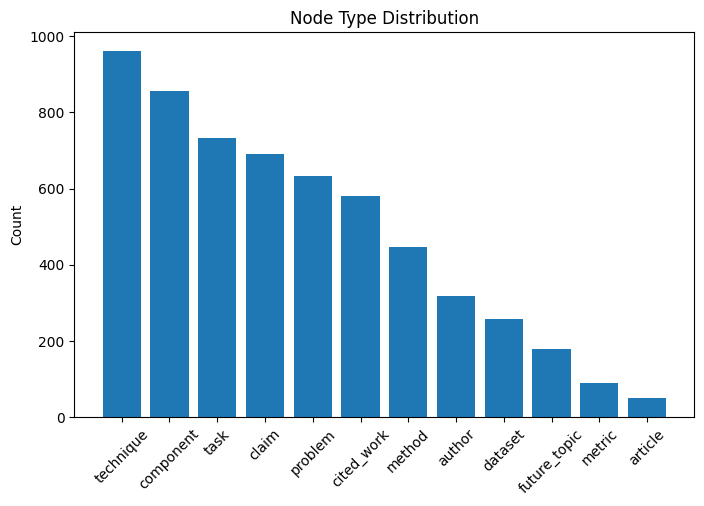

In [18]:
plt.figure(figsize=(8,5))

plt.bar(
    node_type_df["type"],
    node_type_df["count"]
)

plt.xticks(rotation=45)

plt.ylabel("Count")
plt.title("Node Type Distribution")

plt.show()

## 6. Relation type distribution

In [19]:
relation_counts = Counter(
    edge["relation_type"]
    for edge in hyperedges
)


relation_df = (
    pd.DataFrame(
        relation_counts.items(),
        columns=[
            "relation_type",
            "count"
        ]
    )
    .sort_values(
        "count",
        ascending=False
    )
)


relation_df

,relation_type,count
7,claims,690
1,evaluated_on,301
6,presents,52
9,authored_by,51
0,addresses,51
5,uses_technique,51
3,solves,51
2,extends,50
4,uses_component,50
10,proposes_future_work,45


## 7. Hyperedge arity analysis

In [28]:
arities = np.array(
    [
        len(edge["members"])
        for edge in hyperedges
    ]
)


arity_stats = {
    "minimum": int(arities.min()),
    "maximum": int(arities.max()),
    "mean": float(arities.mean()),
    "median": float(np.median(arities)),
    "multiway_fraction": float(np.mean(arities > 2)),
}

arity_stats

{'minimum': 2,
 'maximum': 65,
 'mean': 6.248425472358292,
 'median': 3.0,
 'multiway_fraction': 0.8047585724282715}

### Arity histogram

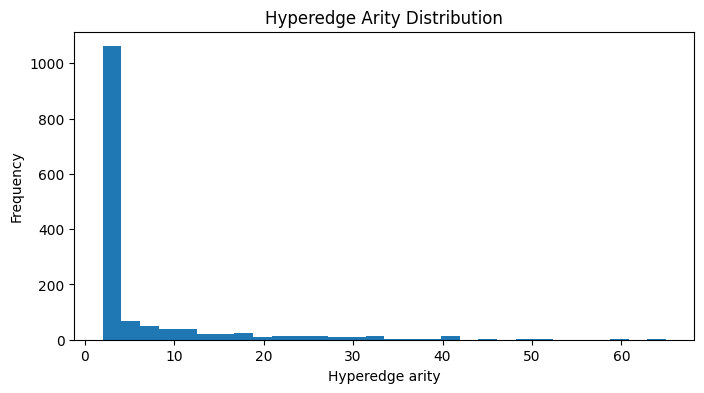

In [21]:
plt.figure(figsize=(8,4))

plt.hist(
    arities,
    bins=30
)

plt.xlabel("Hyperedge arity")
plt.ylabel("Frequency")

plt.title(
    "Hyperedge Arity Distribution"
)

plt.show()

## 8. Temporal node type evolution

This is a stronger T1 analysis.

Question:

Do different node categories emerge at different times?

In [22]:
evolution = []


for year in SNAPSHOT_YEARS:

    counts = Counter(
        node["type"]
        for node in node_snapshots[year]
    )

    row = {
        "year": year
    }

    row.update(counts)

    evolution.append(row)


evolution_df = (
    pd.DataFrame(evolution)
    .fillna(0)
)


evolution_df

,year,article,task,author,technique,method,dataset,component,problem,metric,claim,cited_work,future_topic
0,2020,16,197,105,247,129,74,221,146,34,179,114,43
1,2022,22,263,131,345,189,118,309,198,49,259,214,67
2,2024,38,517,250,673,352,201,608,415,73,505,411,121
3,2026,52,732,318,962,448,259,855,634,90,690,580,178


## 9. Save T1 report

In [29]:
t1_report = {

    "temporal_growth":
        temporal_df.to_dict(
            orient="records"
        ),

    "node_types":
        node_type_df.to_dict(
            orient="records"
        ),

    "relation_types":
        relation_df.to_dict(
            orient="records"
        ),

    "arity_statistics":
        arity_stats

}


with open(
    "t1_statistics.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        t1_report,
        f,
        indent=2
    )


print(
    "T1 report saved."
)

T1 report saved.


In [30]:
with open(
    "t1_statistics.json",
    "r",
    encoding="utf-8"
) as f:

    saved_report = json.load(f)


print("JSON validation passed.")
print(saved_report.keys())

JSON validation passed.
dict_keys(['temporal_growth', 'node_types', 'relation_types', 'arity_statistics'])


## Git Push

In [31]:
from pathlib import Path

CLEAN = Path("/content/drive/MyDrive/Apply/Germany/ConstructorLabs/03_t1_descriptive_statistics.ipynb")
REPO_FILE = Path(
    "/content/tkh-hierarchy-project/"
    "notebooks/03_t1_descriptive_statistics.ipynb"
)

print("Clean file exists:", CLEAN.exists())
print("Repo file exists :", REPO_FILE.exists())

Clean file exists: True
Repo file exists : False
